# KNN Practical and Lazy Learning

## Purpose of This Notebook

This notebook covers the remaining missing topics from the uploaded classification materials.

The focus is on KNN, lazy learning, distance-based classification, KNN imputation, and practical KNN model training.

This notebook is both theory and practice.

We will explain the concepts clearly, apply them on the customer segmentation dataset, and interpret the results.

## What This Notebook Covers

1. Lazy vs eager learners
2. Decision Tree as an eager learner
3. KNN as a lazy learner
4. KNN theory from zero
5. Distance and similarity
6. Euclidean distance
7. Why scaling is important for KNN
8. KNN preprocessing
9. Baseline KNN model training
10. KNN model evaluation
11. Choosing the best `k`
12. Majority voting vs distance voting
13. KNN imputation
14. KNN limitations
15. KNN vs Decision Tree comparison

## Dataset

We will use the same customer segmentation dataset used earlier.

The target column is:

`Segmentation`

The possible customer segments are:

`A`, `B`, `C`, and `D`

This is a supervised multiclass classification problem.

## Notebook Style

Each section follows this structure:

1. Theory explanation
2. Simple example
3. Practical notebook code
4. Output interpretation
5. Business meaning

## 1. Lazy vs Eager Learners

Machine learning models do not all learn in the same way.

Some models learn most of their pattern during training.

Some models wait until prediction time and then compare the new record with old records.

This gives us two important learning styles:

1. Eager learners
2. Lazy learners

## Eager Learner

An eager learner builds a model during training.

It studies the training data and creates rules, boundaries, or patterns before prediction time.

A Decision Tree is an eager learner.

During training, it learns rules such as:

- if age is low, go one way,
- if spending score is low, go another way,
- finally predict a customer segment.

Once the tree is trained, prediction is usually fast because the rules already exist.

## Lazy Learner

A lazy learner does very little work during training.

Instead of building many rules immediately, it stores the training examples.

KNN is a lazy learner.

During prediction, KNN compares the new customer with old customers from the training data.

It finds the most similar customers and uses their segments to make a prediction.

## Simple Difference

| Learning Style | What Happens During Training | What Happens During Prediction | Example Model |
|---|---|---|---|
| Eager learner | Learns rules or patterns early | Uses the learned rules | Decision Tree |
| Lazy learner | Stores the training data | Compares new data with old data | KNN |

## Business Meaning

A Decision Tree is like a rulebook created before prediction.

KNN is like checking old similar customer cases every time a new customer appears.

Both can solve classification problems, but they work very differently.

In [1]:
# Code Cell 1A: Lazy vs Eager Learners Summary

import pandas as pd

# ------------------------------------------------------------
# Step 1: Create a simple comparison table
# ------------------------------------------------------------
# This table explains the difference between:
# - eager learners
# - lazy learners
#
# Decision Tree is eager because it builds rules during training.
# KNN is lazy because it mainly stores data and works during prediction.

learning_style_table = pd.DataFrame({
    "learning_style": [
        "Eager learner",
        "Lazy learner"
    ],
    "simple_meaning": [
        "Learns rules during training",
        "Stores training data and works during prediction"
    ],
    "training_behavior": [
        "Training does more work",
        "Training does less work"
    ],
    "prediction_behavior": [
        "Prediction is usually faster",
        "Prediction can be slower"
    ],
    "example_model": [
        "Decision Tree",
        "KNN"
    ],
    "business_example": [
        "A rulebook is prepared before use",
        "Old similar customer cases are checked when needed"
    ]
})

# ------------------------------------------------------------
# Step 2: Display the comparison
# ------------------------------------------------------------

display(learning_style_table)

,learning_style,simple_meaning,training_behavior,prediction_behavior,example_model,business_example
0,Eager learner,Learns rules during training,Training does more work,Prediction is usually faster,Decision Tree,A rulebook is prepared before use
1,Lazy learner,Stores training data and works during prediction,Training does less work,Prediction can be slower,KNN,Old similar customer cases are checked when ne...


### Lazy vs Eager Learners Interpretation

The table shows the main difference between eager and lazy learners.

A Decision Tree is an eager learner because it learns rules during training.

KNN is a lazy learner because it stores training examples and waits until prediction time to compare customers.

This means:

| Model | Training Time | Prediction Time |
|---|---|---|
| Decision Tree | More work during training | Usually faster prediction |
| KNN | Less work during training | More work during prediction |

For our customer segmentation problem:

- Decision Tree learns rules from old customers.
- KNN compares a new customer with similar old customers.

This difference is important because KNN can become slower when the training dataset becomes large.

## 1.1 Lazy vs Eager Timing Demo

Lazy and eager learners often behave differently during training and prediction.

A Decision Tree usually does more work during training because it builds rules.

KNN usually does less work during training because it mainly stores the training data.

However, during prediction, KNN may need more time because it compares new records with many old training records.

In this small demo, we compare training time and prediction time for:

- Decision Tree
- KNN

This is only a simple timing comparison.  
The full KNN model evaluation will come later.

In [2]:
# Lazy vs Eager Timing Demo

import time
import pandas as pd

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

# ------------------------------------------------------------
# Step 1: Create a simple numeric classification dataset
# ------------------------------------------------------------
# We use a synthetic numeric dataset only for timing.
# This avoids preprocessing distractions at this stage.

demo_features, demo_target = make_classification(
    n_samples=5000,
    n_features=10,
    n_informative=6,
    n_redundant=2,
    n_classes=4,
    random_state=42
)

# ------------------------------------------------------------
# Step 2: Split the data into training and testing parts
# ------------------------------------------------------------

demo_train_features, demo_test_features, demo_train_target, demo_test_target = train_test_split(
    demo_features,
    demo_target,
    test_size=0.20,
    random_state=42,
    stratify=demo_target
)

# ------------------------------------------------------------
# Step 3: Scale the data for KNN
# ------------------------------------------------------------

# KNN depends on distance, so scaling is important.
# Decision Tree does not need scaling, but using the same scaled data
# keeps the timing comparison simple.

scaler = StandardScaler()

demo_train_features_scaled = scaler.fit_transform(demo_train_features)
demo_test_features_scaled = scaler.transform(demo_test_features)

# ------------------------------------------------------------
# Step 4: Create the two models
# ------------------------------------------------------------

tree_model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

knn_model = KNeighborsClassifier(
    n_neighbors=5
)

# ------------------------------------------------------------
# Step 5: Measure Decision Tree training time
# ------------------------------------------------------------

start_time = time.time()
tree_model.fit(demo_train_features_scaled, demo_train_target)
tree_training_time = time.time() - start_time

# ------------------------------------------------------------
# Step 6: Measure Decision Tree prediction time
# ------------------------------------------------------------

start_time = time.time()
tree_predictions = tree_model.predict(demo_test_features_scaled)
tree_prediction_time = time.time() - start_time

# ------------------------------------------------------------
# Step 7: Measure KNN training time
# ------------------------------------------------------------

start_time = time.time()
knn_model.fit(demo_train_features_scaled, demo_train_target)
knn_training_time = time.time() - start_time

# ------------------------------------------------------------
# Step 8: Measure KNN prediction time
# ------------------------------------------------------------

start_time = time.time()
knn_predictions = knn_model.predict(demo_test_features_scaled)
knn_prediction_time = time.time() - start_time

# ------------------------------------------------------------
# Step 9: Create a clean comparison table
# ------------------------------------------------------------

timing_table = pd.DataFrame({
    "model": [
        "Decision Tree",
        "KNN"
    ],
    "learning_style": [
        "Eager learner",
        "Lazy learner"
    ],
    "training_time_seconds": [
        round(tree_training_time, 4),
        round(knn_training_time, 4)
    ],
    "prediction_time_seconds": [
        round(tree_prediction_time, 4),
        round(knn_prediction_time, 4)
    ]
})

display(timing_table)

,model,learning_style,training_time_seconds,prediction_time_seconds
0,Decision Tree,Eager learner,0.0362,0.0012
1,KNN,Lazy learner,0.0044,0.1202


### Timing Demo Interpretation

The timing comparison shows the difference between eager and lazy learning.

| Model | Training Time | Prediction Time | Meaning |
|---|---:|---:|---|
| Decision Tree | 0.0362 sec | 0.0012 sec | More work during training, very fast prediction |
| KNN | 0.0044 sec | 0.1202 sec | Very little work during training, slower prediction |

The Decision Tree takes more time during training because it builds rules.

KNN trains very quickly because it mainly stores the training examples.

However, KNN is slower during prediction because it compares the test records with stored training records.

This confirms the main idea:

- Decision Tree is an eager learner.
- KNN is a lazy learner.

## 2. What Is KNN?

KNN stands for **K-Nearest Neighbors**.

It is a classification algorithm based on similarity.

The main idea is simple:

**To predict a new customer, look at the most similar old customers.**

If most similar old customers belong to Segment `D`, KNN predicts Segment `D`.

If most similar old customers belong to Segment `A`, KNN predicts Segment `A`.

## What Does `K` Mean?

`K` means the number of nearest neighbors used for prediction.

For example:

| K Value | Meaning |
|---:|---|
| `K = 1` | Look at the 1 nearest customer |
| `K = 5` | Look at the 5 nearest customers |
| `K = 15` | Look at the 15 nearest customers |

The model checks the nearest customers and uses their segments to make the final prediction.

## Simple Customer Example

Suppose a new customer is similar to 5 old customers.

| Neighbor | Segment |
|---|---|
| Customer 1 | D |
| Customer 2 | D |
| Customer 3 | A |
| Customer 4 | D |
| Customer 5 | B |

Segment `D` appears most often.

So KNN predicts:

`Segment D`

## Business Meaning

KNN works like case-based reasoning.

It answers:

**Which old customers look most similar to this new customer?**

Then it uses those similar customers to predict the new customer’s segment.

In [3]:
# Code Cell 2A: Simple KNN Voting Example

import pandas as pd

# ------------------------------------------------------------
# Step 1: Create a small nearest-neighbor example
# ------------------------------------------------------------
# This example shows how KNN predicts a segment.
#
# A new customer is compared with old customers.
# The 5 most similar old customers are selected.
# Their segments are used for voting.

nearest_customers = pd.DataFrame({
    "neighbor": [
        "Neighbor 1",
        "Neighbor 2",
        "Neighbor 3",
        "Neighbor 4",
        "Neighbor 5"
    ],
    "old_customer_segment": [
        "D",
        "D",
        "A",
        "D",
        "B"
    ]
})

# ------------------------------------------------------------
# Step 2: Count votes by segment
# ------------------------------------------------------------
# The segment that appears most often wins.

vote_count = (
    nearest_customers["old_customer_segment"]
    .value_counts()
    .reset_index()
)

vote_count.columns = [
    "segment",
    "votes"
]

# ------------------------------------------------------------
# Step 3: Find the winning segment
# ------------------------------------------------------------

predicted_segment = vote_count.loc[0, "segment"]

# ------------------------------------------------------------
# Step 4: Display the result
# ------------------------------------------------------------

print("Nearest customers:")
display(nearest_customers)

print("\nVote count:")
display(vote_count)

print(f"\nPredicted segment for the new customer: {predicted_segment}")

Nearest customers:


,neighbor,old_customer_segment
0,Neighbor 1,D
1,Neighbor 2,D
2,Neighbor 3,A
3,Neighbor 4,D
4,Neighbor 5,B



Vote count:


,segment,votes
0,D,3
1,A,1
2,B,1



Predicted segment for the new customer: D


### Distance Example Interpretation

The distance table shows which old customers are most similar to the new customer.

The smaller the distance, the more similar the old customer is.

KNN uses this idea to find the nearest neighbors.

In this example:

- the old customer with the smallest distance is the closest match,
- the old customer with the largest distance is the least similar,
- the closest customers are used for voting.

This is the core idea of KNN:

**find similar old customers, then use their known segments to predict the new customer segment.**

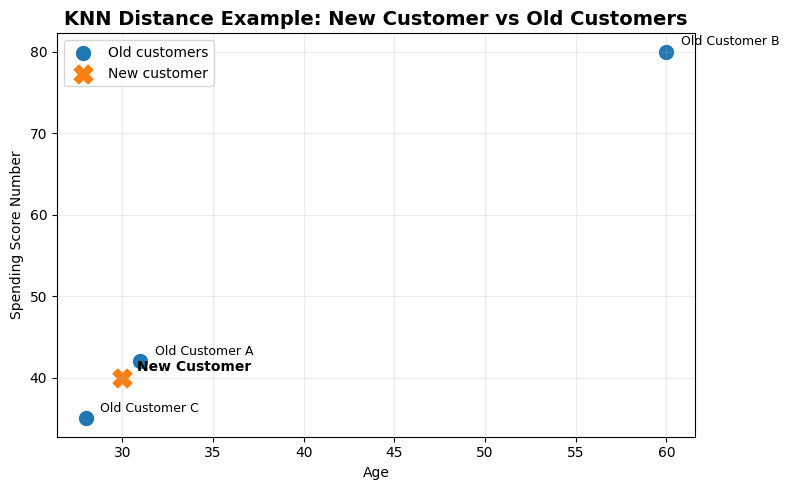

In [5]:
# Code Cell 3B: Visualize Customer Distance

import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Step 1: Recreate the new customer
# ------------------------------------------------------------
# new_customer = the customer whose segment we want to predict

new_customer = {
    "age": 30,
    "spending_score_number": 40
}

# ------------------------------------------------------------
# Step 2: Recreate old customers
# ------------------------------------------------------------
# old_customers = previous customers with known segments
# KNN compares the new customer with these old customers

old_customers = pd.DataFrame({
    "customer": [
        "Old Customer A",
        "Old Customer B",
        "Old Customer C"
    ],
    "age": [
        31,
        60,
        28
    ],
    "spending_score_number": [
        42,
        80,
        35
    ],
    "segment": [
        "D",
        "A",
        "D"
    ]
})

# ------------------------------------------------------------
# Step 3: Create the chart area
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

# ------------------------------------------------------------
# Step 4: Plot old customers
# ------------------------------------------------------------

plt.scatter(
    old_customers["age"],
    old_customers["spending_score_number"],
    s=100,
    label="Old customers"
)

# ------------------------------------------------------------
# Step 5: Plot the new customer
# ------------------------------------------------------------

plt.scatter(
    new_customer["age"],
    new_customer["spending_score_number"],
    s=180,
    marker="X",
    label="New customer"
)

# ------------------------------------------------------------
# Step 6: Add labels for old customers
# ------------------------------------------------------------

for _, row in old_customers.iterrows():
    plt.text(
        row["age"] + 0.8,
        row["spending_score_number"] + 0.8,
        row["customer"],
        fontsize=9
    )

# ------------------------------------------------------------
# Step 7: Add label for new customer
# ------------------------------------------------------------

plt.text(
    new_customer["age"] + 0.8,
    new_customer["spending_score_number"] + 0.8,
    "New Customer",
    fontsize=10,
    fontweight="bold"
)

# ------------------------------------------------------------
# Step 8: Format the chart
# ------------------------------------------------------------

plt.title(
    "KNN Distance Example: New Customer vs Old Customers",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Age")
plt.ylabel("Spending Score Number")

plt.grid(alpha=0.25)
plt.legend()

plt.tight_layout()
plt.show()

### Distance Chart Interpretation

The chart shows one new customer and three old customers.

KNN compares the new customer with old customers and checks which ones are closest.

The closer an old customer is, the more similar it is.

The old customers that are closest become the nearest neighbors.

Their known segments are then used to predict the segment of the new customer.

This is why distance is the core idea behind KNN.

## 4. Why Scaling Is Important for KNN

KNN is based on distance.

It compares customers by calculating how close or far they are from each other.

Because of this, feature scale is very important.

If one feature has much larger values than another feature, it can dominate the distance calculation.

## Simple Example

Imagine we compare customers using two features:

| Feature | Example Range |
|---|---:|
| Age | 18 to 80 |
| Annual Income | 20,000 to 100,000 |

Annual income has much larger numbers than age.

If we calculate distance without scaling, income may dominate the result.

This means KNN may treat income as more important only because the numbers are larger.

That is not fair.

## What Scaling Does

Scaling puts numeric features on a similar range.

After scaling:

- age becomes easier to compare,
- income becomes easier to compare,
- no feature dominates only because of large numbers.

## Business Meaning

For customer segmentation, KNN should compare customers fairly across features.

Features such as age, work experience, and family size should be placed on a comparable scale before KNN is trained.

This is why scaling is required for KNN.

In [7]:
# Code Cell 4A: Why Scaling Matters for KNN

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

# ------------------------------------------------------------
# Step 1: Create a small customer example
# ------------------------------------------------------------
# age has small values.
# annual_income has large values.
#
# Without scaling, annual_income can dominate distance.

customers_for_scaling = pd.DataFrame({
    "customer": [
        "New Customer",
        "Old Customer A",
        "Old Customer B"
    ],
    "age": [
        30,
        32,
        55
    ],
    "annual_income": [
        50000,
        90000,
        51000
    ]
})

display(customers_for_scaling)

# ------------------------------------------------------------
# Step 2: Separate only numeric columns
# ------------------------------------------------------------
# We use only numeric values for distance calculation.

numeric_columns = ["age", "annual_income"]

# New customer numeric values
new_customer_values = (
    customers_for_scaling
    .loc[0, numeric_columns]
    .to_numpy(dtype=float)
)

# Old customers numeric values
old_customer_values = (
    customers_for_scaling
    .loc[1:, numeric_columns]
    .to_numpy(dtype=float)
)

# ------------------------------------------------------------
# Step 3: Calculate distance before scaling
# ------------------------------------------------------------
# Distance = straight-line distance between customers.
#
# Problem:
# annual_income has much larger numbers than age,
# so income dominates the distance before scaling.

distance_before_scaling = np.sqrt(
    ((old_customer_values - new_customer_values) ** 2).sum(axis=1)
)

# ------------------------------------------------------------
# Step 4: Scale numeric columns
# ------------------------------------------------------------
# Scaling puts age and annual_income on a comparable scale.

scaler = StandardScaler()

scaled_values = scaler.fit_transform(
    customers_for_scaling[numeric_columns]
)

# ------------------------------------------------------------
# Step 5: Calculate distance after scaling
# ------------------------------------------------------------

new_customer_scaled = scaled_values[0]
old_customers_scaled = scaled_values[1:]

distance_after_scaling = np.sqrt(
    ((old_customers_scaled - new_customer_scaled) ** 2).sum(axis=1)
)

# ------------------------------------------------------------
# Step 6: Create comparison table
# ------------------------------------------------------------

scaling_distance_table = pd.DataFrame({
    "old_customer": [
        "Old Customer A",
        "Old Customer B"
    ],
    "distance_before_scaling": distance_before_scaling.round(2),
    "distance_after_scaling": distance_after_scaling.round(2)
})

display(scaling_distance_table)

,customer,age,annual_income
0,New Customer,30,50000
1,Old Customer A,32,90000
2,Old Customer B,55,51000


,old_customer,distance_before_scaling,distance_after_scaling
0,Old Customer A,40000.00,2.15
1,Old Customer B,1000.31,2.20


### Scaling Example Interpretation

The table shows why scaling is important for KNN.

Before scaling, `annual_income` has very large values compared with `age`.

Because income values are much larger, income dominates the distance calculation.

After scaling, both features are placed on a comparable scale.

This makes the distance comparison fairer.

For KNN, this is very important because KNN decides similarity using distance.

If we do not scale numeric features, the model may give too much importance to columns with large numbers.

## 5. Load Customer Segmentation Dataset for KNN

Now we move from small examples to the real customer segmentation dataset.

We will use the same dataset used in the previous notebooks.

The target column is:

`Segmentation`

The model will use customer information to predict the customer segment.

KNN needs clean numeric input.

So before training KNN, we need to:

1. load the dataset,
2. separate features and target,
3. split data into training and testing sets,
4. handle missing values,
5. encode categorical columns,
6. scale numeric columns.

This preparation is very important because KNN uses distance.

In [8]:
# Code Cell 5A: Load Customer Segmentation Dataset

import pandas as pd
from pathlib import Path

# ------------------------------------------------------------
# Step 1: Define the dataset folder
# ------------------------------------------------------------
# We use a relative path from the day_7_ml project folder.

data_folder = Path("data/customer_segmentation")

# ------------------------------------------------------------
# Step 2: Find CSV files inside the folder
# ------------------------------------------------------------

csv_files = list(data_folder.glob("*.csv"))

print("CSV files found:")
print("-" * 40)

for file in csv_files:
    print(file.name)

# ------------------------------------------------------------
# Step 3: Find the training file
# ------------------------------------------------------------

train_file = None

for file in csv_files:
    if "train" in file.name.lower():
        train_file = file
        break

if train_file is None:
    raise FileNotFoundError("No training CSV file found.")

# ------------------------------------------------------------
# Step 4: Load the dataset
# ------------------------------------------------------------
# data = full customer segmentation dataset

data = pd.read_csv(train_file)

# ------------------------------------------------------------
# Step 5: Display basic dataset information
# ------------------------------------------------------------

print("\nDataset loaded successfully.")
print("-" * 40)
print(f"Loaded file:       {train_file.name}")
print(f"Number of rows:    {data.shape[0]}")
print(f"Number of columns: {data.shape[1]}")

display(data.head())

CSV files found:
----------------------------------------
Test.csv
Train.csv

Dataset loaded successfully.
----------------------------------------
Loaded file:       Train.csv
Number of rows:    8068
Number of columns: 11


,ID,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1,Segmentation
0,462809,Male,No,22,No,Healthcare,1.0,Low,4.0,Cat_4,D
1,462643,Female,Yes,38,Yes,Engineer,NaN,Average,3.0,Cat_4,A
2,466315,Female,Yes,67,Yes,Engineer,1.0,Low,1.0,Cat_6,B
3,461735,Male,Yes,67,Yes,Lawyer,0.0,High,2.0,Cat_6,B
4,462669,Female,Yes,40,Yes,Entertainment,NaN,High,6.0,Cat_6,A


## 5.1 Features and Target for KNN

Before training KNN, we need to separate the dataset into two parts.

The first part is the customer information.

We call this:

`features`

The second part is the customer segment we want to predict.

We call this:

`target`

The target column is:

`Segmentation`

The `ID` column is not useful for prediction because it is only a customer identifier.

So we remove `ID` from the features.

KNN will later use the remaining customer information to predict the customer segment.

In [9]:
# Code Cell 5B: Create Features and Target

# ------------------------------------------------------------
# Step 1: Check the actual column names
# ------------------------------------------------------------
# This helps us confirm that ID and Segmentation exist correctly.

print("Dataset columns:")
print("-" * 40)
print(data.columns.tolist())

# ------------------------------------------------------------
# Step 2: Define the target column
# ------------------------------------------------------------
# target_column = column we want to predict

target_column = "Segmentation"

# ------------------------------------------------------------
# Step 3: Create features
# ------------------------------------------------------------
# features = customer information used for prediction
#
# We remove:
# - ID because it is only a customer identifier
# - Segmentation because it is the answer we want to predict

features = data.drop(columns=["ID", target_column])

# ------------------------------------------------------------
# Step 4: Create target
# ------------------------------------------------------------
# target = correct customer segment

target = data[target_column]

# ------------------------------------------------------------
# Step 5: Display the result
# ------------------------------------------------------------

print("\nFeatures and target created successfully.")
print("-" * 50)
print(f"features shape: {features.shape}")
print(f"target shape:   {target.shape}")

print("\nFeature columns:")
print(features.columns.tolist())

print("\nTarget labels:")
print(sorted(target.unique()))

display(features.head())
display(target.head())

Dataset columns:
----------------------------------------
['ID', 'Gender', 'Ever_Married', 'Age', 'Graduated', 'Profession', 'Work_Experience', 'Spending_Score', 'Family_Size', 'Var_1', 'Segmentation']

Features and target created successfully.
--------------------------------------------------
features shape: (8068, 9)
target shape:   (8068,)

Feature columns:
['Gender', 'Ever_Married', 'Age', 'Graduated', 'Profession', 'Work_Experience', 'Spending_Score', 'Family_Size', 'Var_1']

Target labels:
['A', 'B', 'C', 'D']


,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1
0,Male,No,22,No,Healthcare,1.0,Low,4.0,Cat_4
1,Female,Yes,38,Yes,Engineer,NaN,Average,3.0,Cat_4
2,Female,Yes,67,Yes,Engineer,1.0,Low,1.0,Cat_6
3,Male,Yes,67,Yes,Lawyer,0.0,High,2.0,Cat_6
4,Female,Yes,40,Yes,Entertainment,NaN,High,6.0,Cat_6


0    D
1    A
2    B
3    B
4    A
Name: Segmentation, dtype: object

## 5.2 Missing Values and Column Types

Before training KNN, we need to inspect the feature columns.

KNN needs clean numeric input.

However, the dataset contains:

1. numeric columns,
2. categorical columns,
3. missing values.

Numeric columns contain numbers, such as:

- `Age`
- `Work_Experience`
- `Family_Size`

Categorical columns contain text labels, such as:

- `Gender`
- `Ever_Married`
- `Graduated`
- `Profession`
- `Spending_Score`
- `Var_1`

For KNN, we need to prepare these columns carefully.

Numeric columns will be imputed and scaled.

Categorical columns will be imputed and one-hot encoded.

This preparation is important because KNN calculates distance between customers.

In [10]:
# Code Cell 5C: Check Missing Values and Column Types

# ------------------------------------------------------------
# Step 1: Identify numeric columns
# ------------------------------------------------------------
# numeric_columns = columns with number values

numeric_columns = features.select_dtypes(include=["int64", "float64"]).columns.tolist()

# ------------------------------------------------------------
# Step 2: Identify categorical columns
# ------------------------------------------------------------
# categorical_columns = columns with text/category values

categorical_columns = features.select_dtypes(include=["object"]).columns.tolist()

# ------------------------------------------------------------
# Step 3: Check missing values
# ------------------------------------------------------------
# missing_table shows how many missing values each feature has.

missing_table = (
    features
    .isna()
    .sum()
    .reset_index()
)

missing_table.columns = [
    "feature",
    "missing_values"
]

missing_table["missing_percentage"] = (
    missing_table["missing_values"] / len(features) * 100
).round(2)

missing_table = missing_table.sort_values(
    by="missing_values",
    ascending=False
)

# ------------------------------------------------------------
# Step 4: Display results
# ------------------------------------------------------------

print("Numeric columns:")
print(numeric_columns)

print("\nCategorical columns:")
print(categorical_columns)

print("\nMissing values:")
display(missing_table)

Numeric columns:
['Age', 'Work_Experience', 'Family_Size']

Categorical columns:
['Gender', 'Ever_Married', 'Graduated', 'Profession', 'Spending_Score', 'Var_1']

Missing values:


,feature,missing_values,missing_percentage
5,Work_Experience,829,10.28
7,Family_Size,335,4.15
1,Ever_Married,140,1.74
4,Profession,124,1.54
3,Graduated,78,0.97
8,Var_1,76,0.94
0,Gender,0,0.00
2,Age,0,0.00
6,Spending_Score,0,0.00


### Missing Values and Column Types Interpretation

The dataset contains both numeric and categorical features.

The numeric features are:

- `Age`
- `Work_Experience`
- `Family_Size`

The categorical features are:

- `Gender`
- `Ever_Married`
- `Graduated`
- `Profession`
- `Spending_Score`
- `Var_1`

Some columns contain missing values.

For KNN, missing values must be handled before training.

We will use:

| Column Type | Missing-Value Strategy |
|---|---|
| Numeric columns | Fill missing values with the median |
| Categorical columns | Fill missing values with the most common value |

After that:

- numeric columns will be scaled,
- categorical columns will be one-hot encoded.

This gives KNN clean numeric input for distance calculation.

## 5.3 Train/Test Split for KNN

Before preprocessing and training the KNN model, we split the data into training and testing parts.

The training data is used to fit the preprocessing steps and train the model.

The testing data is kept separate and used only for final evaluation.

This is important because the model should be tested on unseen customers.

We also use `stratify=target` so that customer segment proportions stay similar in both training and testing data.

In [11]:
# Code Cell 5D: Create Train and Test Data

from sklearn.model_selection import train_test_split

# ------------------------------------------------------------
# Step 1: Split features and target into train and test data
# ------------------------------------------------------------
# features = customer information
# target = correct customer segment
#
# train_features = customer information used for training
# test_features = customer information used for testing
# train_target = correct segments for training customers
# test_target = correct segments for testing customers

train_features, test_features, train_target, test_target = train_test_split(
    features,
    target,
    test_size=0.20,
    random_state=42,
    stratify=target
)

# ------------------------------------------------------------
# Step 2: Display split sizes
# ------------------------------------------------------------

print("Train/test split completed.")
print("-" * 45)
print(f"train_features shape: {train_features.shape}")
print(f"test_features shape:  {test_features.shape}")
print(f"train_target shape:   {train_target.shape}")
print(f"test_target shape:    {test_target.shape}")

Train/test split completed.
---------------------------------------------
train_features shape: (6454, 9)
test_features shape:  (1614, 9)
train_target shape:   (6454,)
test_target shape:    (1614,)


## 6. KNN Preprocessing Pipeline

KNN calculates distance between customers.

Because of this, the input data must be clean and numeric.

The customer segmentation dataset contains both numeric and categorical features.

Numeric features include:

- `Age`
- `Work_Experience`
- `Family_Size`

Categorical features include:

- `Gender`
- `Ever_Married`
- `Graduated`
- `Profession`
- `Spending_Score`
- `Var_1`

Before training KNN, we need to prepare these features.

## Numeric Preprocessing

For numeric columns, we will:

1. fill missing values using the median,
2. scale the values using `StandardScaler`.

Scaling is important because KNN uses distance.

If one numeric feature has larger values than another, it can dominate the distance calculation.

## Categorical Preprocessing

For categorical columns, we will:

1. fill missing values using the most common value,
2. convert text categories into numeric columns using one-hot encoding.

KNN cannot directly use text values such as `Male`, `Artist`, or `Low`.

One-hot encoding converts these categories into numeric 0/1 columns.

## Why We Use ColumnTransformer

`ColumnTransformer` lets us apply different preprocessing steps to different column types.

This means:

- numeric columns get numeric preprocessing,
- categorical columns get categorical preprocessing.

After this step, all features will be ready for KNN.

In [12]:
# Code Cell 6A: Create KNN Preprocessing Pipeline

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# ------------------------------------------------------------
# Step 1: Create numeric preprocessing steps
# ------------------------------------------------------------
# Numeric columns:
# - fill missing values with median
# - scale values for fair distance calculation

numeric_preprocessing = Pipeline(steps=[
    ("fill_missing_values", SimpleImputer(strategy="median")),
    ("scale_values", StandardScaler())
])

# ------------------------------------------------------------
# Step 2: Create categorical preprocessing steps
# ------------------------------------------------------------
# Categorical columns:
# - fill missing values with most common category
# - convert text categories into 0/1 numeric columns

categorical_preprocessing = Pipeline(steps=[
    ("fill_missing_values", SimpleImputer(strategy="most_frequent")),
    ("one_hot_encode", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

# ------------------------------------------------------------
# Step 3: Combine both preprocessing parts
# ------------------------------------------------------------
# ColumnTransformer applies:
# - numeric_preprocessing to numeric_columns
# - categorical_preprocessing to categorical_columns

preprocessing = ColumnTransformer(transformers=[
    ("numeric", numeric_preprocessing, numeric_columns),
    ("categorical", categorical_preprocessing, categorical_columns)
])

print("KNN preprocessing pipeline created successfully.")
print("-" * 55)
print("Numeric columns:")
print(numeric_columns)

print("\nCategorical columns:")
print(categorical_columns)

KNN preprocessing pipeline created successfully.
-------------------------------------------------------
Numeric columns:
['Age', 'Work_Experience', 'Family_Size']

Categorical columns:
['Gender', 'Ever_Married', 'Graduated', 'Profession', 'Spending_Score', 'Var_1']


## 6.1 Apply Preprocessing to Train and Test Data

Now we apply the preprocessing pipeline.

The preprocessing pipeline will:

1. fill missing numeric values with the median,
2. scale numeric columns,
3. fill missing categorical values with the most common value,
4. one-hot encode categorical columns.

We fit the preprocessing pipeline only on the training data.

This is important because the test data should remain unseen.

After fitting on the training data, we apply the same learned preprocessing rules to the test data.

This avoids data leakage.

In [13]:
# Code Cell 6B: Apply Preprocessing to Train and Test Data

# ------------------------------------------------------------
# Step 1: Fit preprocessing on training data
# ------------------------------------------------------------
# fit_transform learns preprocessing rules from train_features:
# - median values for numeric missing values
# - most common values for categorical missing values
# - scaling mean and standard deviation
# - one-hot encoded category structure
#
# It then transforms train_features into clean numeric data.

train_features_processed = preprocessing.fit_transform(train_features)

# ------------------------------------------------------------
# Step 2: Apply same preprocessing to test data
# ------------------------------------------------------------
# transform uses the rules learned from train_features.
# We do NOT fit on test_features because test data must stay unseen.

test_features_processed = preprocessing.transform(test_features)

# ------------------------------------------------------------
# Step 3: Check processed data shapes
# ------------------------------------------------------------

print("Preprocessing completed successfully.")
print("-" * 55)
print(f"Original train_features shape:   {train_features.shape}")
print(f"Processed train_features shape:  {train_features_processed.shape}")

print(f"\nOriginal test_features shape:    {test_features.shape}")
print(f"Processed test_features shape:   {test_features_processed.shape}")

Preprocessing completed successfully.
-------------------------------------------------------
Original train_features shape:   (6454, 9)
Processed train_features shape:  (6454, 28)

Original test_features shape:    (1614, 9)
Processed test_features shape:   (1614, 28)


### Preprocessing Interpretation

The preprocessing step converted the original customer data into clean numeric data for KNN.

The original dataset had 9 feature columns.

After preprocessing, the number of columns increased because categorical columns were one-hot encoded.

This is expected.

For example, a column like `Profession` becomes multiple numeric columns such as:

- `Profession_Artist`
- `Profession_Engineer`
- `Profession_Healthcare`

The processed data is now ready for KNN because:

- missing values are handled,
- numeric columns are scaled,
- categorical columns are converted into numbers,
- train and test data are processed consistently.

## 7. Baseline KNN Model

Now we train the first KNN model.

This is our baseline KNN model.

A baseline model is the first simple version of a model.

It gives us a starting point before tuning.

For this first model, we use:

`n_neighbors=5`

This means KNN will look at the 5 nearest training customers when predicting the segment of a test customer.

The predicted segment is decided by majority vote.

For example, if the 5 nearest customers have these segments:

| Neighbor | Segment |
|---|---|
| 1 | D |
| 2 | D |
| 3 | A |
| 4 | D |
| 5 | B |

Segment `D` gets the most votes.

So KNN predicts Segment `D`.

In this step, we will:

1. create a KNN model,
2. train it on the processed training data,
3. predict customer segments for training and test data,
4. calculate train and test accuracy.

In [14]:
# Code Cell 7A: Train Baseline KNN Model

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# ------------------------------------------------------------
# Step 1: Create the baseline KNN model
# ------------------------------------------------------------
# n_neighbors=5 means:
# for each new customer, KNN checks the 5 nearest training customers.

knn_model = KNeighborsClassifier(
    n_neighbors=5
)

# ------------------------------------------------------------
# Step 2: Train the KNN model
# ------------------------------------------------------------
# train_features_processed = cleaned numeric training data
# train_target = correct customer segments for training data

knn_model.fit(
    train_features_processed,
    train_target
)

# ------------------------------------------------------------
# Step 3: Make predictions
# ------------------------------------------------------------
# train_predictions = predictions on training data
# test_predictions = predictions on unseen test data

train_predictions = knn_model.predict(train_features_processed)
test_predictions = knn_model.predict(test_features_processed)

# ------------------------------------------------------------
# Step 4: Calculate accuracy
# ------------------------------------------------------------
# accuracy = percentage of correct predictions

train_accuracy = accuracy_score(
    train_target,
    train_predictions
)

test_accuracy = accuracy_score(
    test_target,
    test_predictions
)

# ------------------------------------------------------------
# Step 5: Display results
# ------------------------------------------------------------

print("Baseline KNN model trained successfully.")
print("-" * 50)
print(f"Training accuracy: {train_accuracy:.4f}")
print(f"Test accuracy:     {test_accuracy:.4f}")
print(f"Train-test gap:    {train_accuracy - test_accuracy:.4f}")

Baseline KNN model trained successfully.
--------------------------------------------------
Training accuracy: 0.6264
Test accuracy:     0.4796
Train-test gap:    0.1469


### Baseline KNN Interpretation

The baseline KNN model was trained with `n_neighbors=5`.

| Metric | Value |
|---|---:|
| Training accuracy | 0.6264 |
| Test accuracy | 0.4796 |
| Train-test gap | 0.1469 |

The training accuracy is higher than the test accuracy.

This means the model performs better on customers it has already seen than on unseen customers.

The train-test gap is around `0.1469`, which suggests some overfitting.

This is common with KNN when `k` is relatively small.

Later, we will test different `k` values to see whether a larger `k` improves generalization.

## 7.1 KNN Classification Report

Accuracy gives one overall score.

However, in multiclass classification, we should also check how the model performs for each segment.

The classification report shows:

| Metric | Meaning |
|---|---|
| Precision | When the model predicts a segment, how often is it correct? |
| Recall | Out of the real customers in a segment, how many did the model find? |
| F1-score | Balanced score between precision and recall |
| Support | Number of real customers in each segment |

This helps us understand whether KNN performs equally well across all customer segments or struggles with specific segments.

In [15]:
# Code Cell 7B: KNN Classification Report

from sklearn.metrics import classification_report

# ------------------------------------------------------------
# Step 1: Create classification report
# ------------------------------------------------------------
# test_target = correct customer segments from test data
# test_predictions = KNN predicted customer segments

knn_report = classification_report(
    test_target,
    test_predictions,
    output_dict=True
)

# ------------------------------------------------------------
# Step 2: Convert report into a clean table
# ------------------------------------------------------------

knn_report_table = pd.DataFrame(knn_report).T.round(3)

# ------------------------------------------------------------
# Step 3: Display report
# ------------------------------------------------------------

display(knn_report_table)

,precision,recall,f1-score,support
A,0.372,0.442,0.404,394.00
B,0.348,0.331,0.339,372.00
C,0.544,0.520,0.532,394.00
D,0.654,0.599,0.625,454.00
accuracy,0.480,0.480,0.480,0.48
macro avg,0.479,0.473,0.475,1614.00
weighted avg,0.488,0.480,0.482,1614.00


### KNN Classification Report Interpretation

The baseline KNN model achieved a test accuracy of `0.480`.

This means the model correctly predicted around 48% of test customers.

## Segment-Level Performance

| Segment | F1-score | Interpretation |
|---|---:|---|
| A | 0.404 | Moderate performance |
| B | 0.339 | Weakest performance |
| C | 0.532 | Good compared with A and B |
| D | 0.625 | Best performing segment |

Segment `D` has the best F1-score.

Segment `B` has the weakest F1-score.

This means KNN is better at identifying Segment `D` customers than Segment `B` customers.

The macro average F1-score is `0.475`.

The weighted average F1-score is `0.482`.

These values are close, which makes sense because the target classes are reasonably balanced.

Overall, the baseline KNN model works, but it is not yet optimized.

Next, we will use a confusion matrix to understand where the model is making mistakes.

## 7.2 KNN Confusion Matrix

A confusion matrix shows where the model is correct and where it is confused.

Rows show the actual customer segment.

Columns show the predicted customer segment.

The diagonal values show correct predictions.

The off-diagonal values show mistakes.

This helps us understand which segments are being confused with each other.

<Figure size 700x600 with 0 Axes>

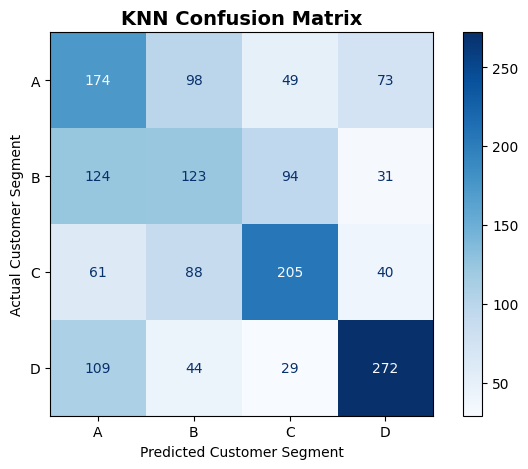

In [16]:
# Code Cell 7C: KNN Confusion Matrix

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# ------------------------------------------------------------
# Step 1: Define segment labels in correct order
# ------------------------------------------------------------

segment_labels = ["A", "B", "C", "D"]

# ------------------------------------------------------------
# Step 2: Create confusion matrix
# ------------------------------------------------------------
# test_target = actual customer segments
# test_predictions = KNN predicted customer segments

knn_confusion_matrix = confusion_matrix(
    test_target,
    test_predictions,
    labels=segment_labels
)

# ------------------------------------------------------------
# Step 3: Plot confusion matrix
# ------------------------------------------------------------

plt.figure(figsize=(7, 6))

display_matrix = ConfusionMatrixDisplay(
    confusion_matrix=knn_confusion_matrix,
    display_labels=segment_labels
)

display_matrix.plot(
    values_format="d",
    cmap="Blues"
)

plt.title(
    "KNN Confusion Matrix",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Predicted Customer Segment")
plt.ylabel("Actual Customer Segment")

plt.tight_layout()
plt.show()

In [17]:
# Code Cell 7D: Confusion Matrix as Table

import pandas as pd

# ------------------------------------------------------------
# Step 1: Convert confusion matrix into a readable table
# ------------------------------------------------------------
# Rows = actual customer segments
# Columns = predicted customer segments

confusion_matrix_table = pd.DataFrame(
    knn_confusion_matrix,
    index=[f"Actual {label}" for label in segment_labels],
    columns=[f"Predicted {label}" for label in segment_labels]
)

# ------------------------------------------------------------
# Step 2: Display the table
# ------------------------------------------------------------

display(confusion_matrix_table)

,Predicted A,Predicted B,Predicted C,Predicted D
Actual A,174,98,49,73
Actual B,124,123,94,31
Actual C,61,88,205,40
Actual D,109,44,29,272


### Confusion Matrix Result Interpretation

The confusion matrix shows that KNN performs best on Segment `D`.

Segment `D` has `272` correct predictions out of `454` actual Segment D customers.

Segment `C` also performs reasonably well, with `205` correct predictions out of `394`.

The weaker segments are `A` and `B`.

Segment `B` is the weakest because only `123` out of `372` actual Segment B customers were correctly predicted as B.

The main confusion patterns are:

| Actual Segment | Common Wrong Predictions |
|---|---|
| A | B and D |
| B | A and C |
| C | B |
| D | A |

This means KNN has difficulty separating some neighboring customer segments, especially Segment `A` and Segment `B`.

In [18]:
# Code Cell 7E: KNN Prediction Distribution

# ------------------------------------------------------------
# Step 1: Count predicted segments
# ------------------------------------------------------------
# test_predictions = predicted customer segments from KNN

prediction_count = pd.Series(test_predictions).value_counts().sort_index()

# ------------------------------------------------------------
# Step 2: Calculate prediction percentages
# ------------------------------------------------------------

prediction_percentage = (
    pd.Series(test_predictions)
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

# ------------------------------------------------------------
# Step 3: Create prediction summary table
# ------------------------------------------------------------

prediction_distribution = pd.DataFrame({
    "predicted_segment": prediction_count.index,
    "prediction_count": prediction_count.values,
    "prediction_percentage": prediction_percentage.values
})

# ------------------------------------------------------------
# Step 4: Display result
# ------------------------------------------------------------

display(prediction_distribution)

,predicted_segment,prediction_count,prediction_percentage
0,A,468,29.00
1,B,353,21.87
2,C,377,23.36
3,D,416,25.77


### Prediction Distribution Interpretation

The prediction distribution shows how often KNN predicted each customer segment.

| Predicted Segment | Prediction Count | Prediction Percentage |
|---|---:|---:|
| A | 468 | 29.00% |
| B | 353 | 21.87% |
| C | 377 | 23.36% |
| D | 416 | 25.77% |

KNN predicted Segment `A` most often.

Segment `B` was predicted least often.

The predictions are not extremely unbalanced, but the model slightly over-predicts Segment `A`.

This supports what we saw in the confusion matrix:

- Segment `D` and `C` are predicted better.
- Segment `B` is harder for the model.
- Some Segment `B` customers are confused with Segment `A` and Segment `C`.

Next, we will test different `k` values to see whether the KNN model improves.

## 8. Choosing the Best k Value

In KNN, `k` means the number of nearest neighbors used for prediction.

For example:

| k Value | Meaning |
|---:|---|
| 1 | Use only the 1 nearest customer |
| 5 | Use the 5 nearest customers |
| 15 | Use the 15 nearest customers |

The value of `k` strongly affects model behavior.

## Small k

A small `k` makes the model very sensitive.

For example, if `k=1`, the model only follows the nearest customer.

This can overfit because one unusual customer can strongly affect the prediction.

## Large k

A large `k` makes the model smoother.

For example, if `k=31`, the model checks many neighbors.

This can reduce overfitting, but if `k` becomes too large, the model may become too general and miss local patterns.

## Goal

We test multiple `k` values and compare training accuracy and test accuracy.

A good `k` should:

- perform reasonably well on test data,
- reduce overfitting,
- avoid a very large train-test gap.

In [19]:
# Code Cell 8A: Test Multiple k Values

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import pandas as pd

# ------------------------------------------------------------
# Step 1: Define k values to test
# ------------------------------------------------------------
# Small k values can overfit.
# Larger k values can smooth the model.

k_values = [1, 3, 5, 7, 9, 15, 21, 31]

# ------------------------------------------------------------
# Step 2: Train and evaluate one KNN model for each k
# ------------------------------------------------------------

k_results = []

for k in k_values:
    
    # Create KNN model with current k
    model = KNeighborsClassifier(
        n_neighbors=k
    )
    
    # Train model on processed training data
    model.fit(
        train_features_processed,
        train_target
    )
    
    # Predict on training and test data
    train_predictions = model.predict(train_features_processed)
    test_predictions = model.predict(test_features_processed)
    
    # Calculate accuracy
    train_accuracy = accuracy_score(train_target, train_predictions)
    test_accuracy = accuracy_score(test_target, test_predictions)
    
    # Store results
    k_results.append({
        "k": k,
        "train_accuracy": round(train_accuracy, 4),
        "test_accuracy": round(test_accuracy, 4),
        "train_test_gap": round(train_accuracy - test_accuracy, 4)
    })

# ------------------------------------------------------------
# Step 3: Create results table
# ------------------------------------------------------------

k_results_table = pd.DataFrame(k_results)

display(k_results_table)

,k,train_accuracy,test_accuracy,train_test_gap
0,1,0.9531,0.4424,0.5107
1,3,0.6884,0.4758,0.2126
2,5,0.6264,0.4796,0.1469
3,7,0.6077,0.4808,0.1269
4,9,0.5902,0.4963,0.0939
5,15,0.5668,0.5192,0.0476
6,21,0.5555,0.5204,0.0350
7,31,0.5499,0.5186,0.0313


### k Value Comparison Interpretation

The table shows how KNN performance changes when we change `k`.

When `k=1`, the training accuracy is very high at `0.9531`, but the test accuracy is only `0.4424`.

This means the model is strongly overfitting.

It remembers the training data too closely and does not generalize well to unseen customers.

As `k` increases, the training accuracy decreases, but the test accuracy improves.

This is a good sign because the model becomes less sensitive to individual training customers.

The best test accuracy in this comparison is reached at:

| Best k | Test Accuracy | Train-Test Gap |
|---:|---:|---:|
| 21 | 0.5204 | 0.0350 |

This means `k=21` gives the best balance in this experiment.

The model is less overfitted and performs better on unseen customers than the baseline `k=5` model.

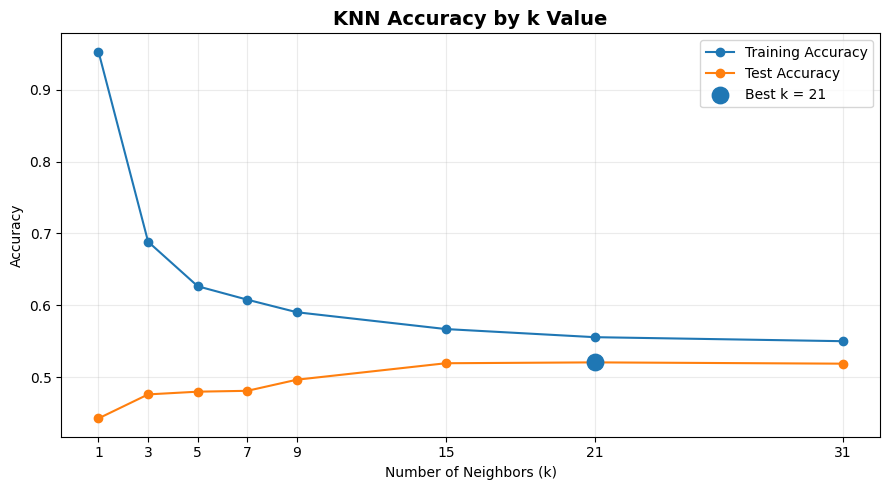

In [20]:
# Code Cell 8B: k Value Accuracy Chart

import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Step 1: Create the chart area
# ------------------------------------------------------------

plt.figure(figsize=(9, 5))

# ------------------------------------------------------------
# Step 2: Plot training accuracy
# ------------------------------------------------------------
# This shows how well each k performs on training data.

plt.plot(
    k_results_table["k"],
    k_results_table["train_accuracy"],
    marker="o",
    label="Training Accuracy"
)

# ------------------------------------------------------------
# Step 3: Plot test accuracy
# ------------------------------------------------------------
# This shows how well each k performs on unseen test data.

plt.plot(
    k_results_table["k"],
    k_results_table["test_accuracy"],
    marker="o",
    label="Test Accuracy"
)

# ------------------------------------------------------------
# Step 4: Highlight best test k
# ------------------------------------------------------------

best_k_row = k_results_table.loc[
    k_results_table["test_accuracy"].idxmax()
]

plt.scatter(
    best_k_row["k"],
    best_k_row["test_accuracy"],
    s=140,
    zorder=5,
    label=f"Best k = {int(best_k_row['k'])}"
)

# ------------------------------------------------------------
# Step 5: Format the chart
# ------------------------------------------------------------

plt.title(
    "KNN Accuracy by k Value",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Number of Neighbors (k)")
plt.ylabel("Accuracy")

plt.xticks(k_results_table["k"])
plt.grid(alpha=0.25)
plt.legend()

plt.tight_layout()
plt.show()

# KNN Voting

| Voting Type              | Meaning                            |
| ------------------------ | ---------------------------------- |
| Majority voting          | Every neighbor gets equal vote     |
| Distance-weighted voting | Closer neighbors get stronger vote |


## 9. Majority Voting vs Distance-Weighted Voting

KNN predicts a customer segment by looking at nearby customers.

There are two common voting methods:

1. Majority voting
2. Distance-weighted voting

## Majority Voting

Majority voting means every neighbor gets the same voting power.

If we use `k=5`, then all 5 neighbors vote equally.

The segment with the most votes becomes the prediction.

In sklearn, this is:

`weights="uniform"`

## Distance-Weighted Voting

Distance-weighted voting means closer neighbors get stronger voting power.

A very close customer is treated as more important than a far-away customer.

In sklearn, this is:

`weights="distance"`

## Simple Difference

| Voting Method | Simple Meaning |
|---|---|
| `weights="uniform"` | Every neighbor vote counts equally |
| `weights="distance"` | Closer neighbors count more |

Distance-weighted voting can help when the nearest customers are much more relevant than farther customers.

In [21]:
# Code Cell 9A: Compare Uniform and Distance Voting

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import pandas as pd

# ------------------------------------------------------------
# Step 1: Define voting methods to compare
# ------------------------------------------------------------
# uniform = all neighbors vote equally
# distance = closer neighbors get stronger voting power

voting_methods = [
    "uniform",
    "distance"
]

# ------------------------------------------------------------
# Step 2: Train and evaluate KNN for each voting method
# ------------------------------------------------------------
# We use k=21 because it gave the best test accuracy
# in the previous k comparison.

voting_results = []

for voting_method in voting_methods:
    
    # Create KNN model
    model = KNeighborsClassifier(
        n_neighbors=21,
        weights=voting_method
    )
    
    # Train model
    model.fit(
        train_features_processed,
        train_target
    )
    
    # Predict train and test data
    train_predictions = model.predict(train_features_processed)
    test_predictions = model.predict(test_features_processed)
    
    # Calculate accuracy
    train_accuracy = accuracy_score(train_target, train_predictions)
    test_accuracy = accuracy_score(test_target, test_predictions)
    
    # Store result
    voting_results.append({
        "voting_method": voting_method,
        "k": 21,
        "train_accuracy": round(train_accuracy, 4),
        "test_accuracy": round(test_accuracy, 4),
        "train_test_gap": round(train_accuracy - test_accuracy, 4)
    })

# ------------------------------------------------------------
# Step 3: Create result table
# ------------------------------------------------------------

voting_results_table = pd.DataFrame(voting_results)

display(voting_results_table)

,voting_method,k,train_accuracy,test_accuracy,train_test_gap
0,uniform,21,0.5555,0.5204,0.0350
1,distance,21,0.9558,0.5025,0.4534


### Voting Method Comparison Interpretation

The voting comparison shows that `uniform` voting performs better than `distance` voting for this dataset.

With `weights="uniform"`, all 21 nearest neighbors vote equally.

This gives a test accuracy of `0.5204` and a small train-test gap of `0.0350`.

With `weights="distance"`, closer neighbors receive stronger voting power.

However, this causes strong overfitting in this experiment.

The training accuracy becomes very high at `0.9558`, but the test accuracy is only `0.5025`.

This means the model is fitting the training data too closely and not generalizing as well to unseen customers.

For this KNN experiment, the better model is:

| Setting | Selected Value |
|---|---|
| `n_neighbors` | `21` |
| `weights` | `"uniform"` |

This model gives the best balance between test accuracy and generalization.

## 10. KNN Limitations

KNN is simple and easy to understand, but it also has important limitations.

KNN works by comparing a new customer with old customers.

This makes it useful when similar customers really behave similarly.

However, KNN can become weaker when:

1. the dataset becomes very large,
2. there are too many features,
3. features are not scaled,
4. noisy or irrelevant columns are included,
5. many customers look similar across different segments.

## Main Limitations

| Limitation | Simple Meaning |
|---|---|
| Slow prediction | KNN compares new records with many old records |
| Needs scaling | Distance becomes unfair if numeric columns have different scales |
| Sensitive to irrelevant features | Useless columns can distort distance |
| Sensitive to noise | Strange training records can affect predictions |
| Curse of dimensionality | Distance becomes less meaningful when there are too many features |

## Curse of Dimensionality

The curse of dimensionality means that distance becomes harder to use when the dataset has many features.

In low dimensions, nearby customers are easier to identify.

In high dimensions, many customers may start looking similarly far apart.

This makes it harder for KNN to find truly meaningful neighbors.

## Business Meaning

KNN can be useful for customer segmentation, but it needs careful preprocessing.

It works best when:

- features are meaningful,
- numeric values are scaled,
- irrelevant columns are removed,
- the number of features is not too large,
- similar customers really belong to similar segments.

In [22]:
# Code Cell 10A: KNN Limitations Summary Table

import pandas as pd

# ------------------------------------------------------------
# Step 1: Create a simple limitations table
# ------------------------------------------------------------
# This table summarizes the practical weaknesses of KNN.

knn_limitations_table = pd.DataFrame({
    "limitation": [
        "Slow prediction",
        "Needs scaling",
        "Sensitive to irrelevant features",
        "Sensitive to noisy records",
        "Curse of dimensionality"
    ],
    "simple_meaning": [
        "KNN compares new customers with stored training customers",
        "Large-value columns can dominate distance",
        "Unhelpful columns can make similarity calculation worse",
        "Unusual customers can affect nearest-neighbor voting",
        "Distance becomes less useful when there are too many features"
    ],
    "business_risk": [
        "Prediction may become slow with large customer databases",
        "Model may compare customers unfairly",
        "Model may find wrong neighbors",
        "Predictions may become unstable",
        "Similar customers become harder to identify"
    ],
    "practical_solution": [
        "Use efficient search methods or smaller feature sets",
        "Apply StandardScaler or another scaling method",
        "Remove irrelevant features",
        "Clean data and test different k values",
        "Use feature selection or dimensionality reduction"
    ]
})

# ------------------------------------------------------------
# Step 2: Display the table
# ------------------------------------------------------------

display(knn_limitations_table)

,limitation,simple_meaning,business_risk,practical_solution
0,Slow prediction,KNN compares new customers with stored trainin...,Prediction may become slow with large customer...,Use efficient search methods or smaller featur...
1,Needs scaling,Large-value columns can dominate distance,Model may compare customers unfairly,Apply StandardScaler or another scaling method
2,Sensitive to irrelevant features,Unhelpful columns can make similarity calculat...,Model may find wrong neighbors,Remove irrelevant features
3,Sensitive to noisy records,Unusual customers can affect nearest-neighbor ...,Predictions may become unstable,Clean data and test different k values
4,Curse of dimensionality,Distance becomes less useful when there are to...,Similar customers become harder to identify,Use feature selection or dimensionality reduction


### KNN Limitations Interpretation

KNN is easy to understand, but it needs careful preparation.

The most important point is that KNN depends on distance.

If the data has wrong scales, missing values, irrelevant columns, or too many features, the distance calculation becomes weaker.

For this customer segmentation dataset, we handled the main KNN risks by:

- removing the `ID` column,
- filling missing values,
- one-hot encoding categorical columns,
- scaling numeric columns,
- testing different `k` values,
- comparing voting methods.

This helped us build a more reliable KNN model.

# KNN Imputation

| Method                   | Simple idea                                         |
| ------------------------ | --------------------------------------------------- |
| Median imputation        | Fill missing numeric value with the middle value    |
| Most frequent imputation | Fill missing category with the most common category |
| KNN imputation           | Fill missing value using similar rows               |


KNN imputation says:

“Find similar customers and use their values to estimate the missing value.”

## 11. KNN Imputation

KNN can also be used for missing-value imputation.

Imputation means filling missing values.

Earlier, we used simple imputation:

| Column Type | Simple Imputation Method |
|---|---|
| Numeric columns | Fill with median |
| Categorical columns | Fill with most common value |

KNN imputation works differently.

Instead of filling a missing value with one general value, KNN imputation looks for similar rows.

It then uses those similar rows to estimate the missing value.

## Simple Example

Suppose a customer is missing `Family_Size`.

KNN imputation looks for customers with similar values in other columns.

Then it estimates the missing `Family_Size` based on those similar customers.

## Important Point

KNNImputer works with numeric data.

It cannot directly use text values such as `Male`, `Artist`, or `Low`.

So for a simple demonstration, we will use only numeric columns:

- `Age`
- `Work_Experience`
- `Family_Size`

## Business Meaning

KNN imputation can be useful when missing values may depend on similar customer behavior.

However, it can be slower than simple imputation and must be used carefully.

In [23]:
# Code Cell 11A: KNN Imputation Mini-Lab

import pandas as pd
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import StandardScaler

# ------------------------------------------------------------
# Step 1: Select numeric columns only
# ------------------------------------------------------------
# KNNImputer needs numeric input.
# We use only numeric customer features for this mini-lab.

numeric_data = data[["Age", "Work_Experience", "Family_Size"]].copy()

# ------------------------------------------------------------
# Step 2: Check missing values before imputation
# ------------------------------------------------------------

missing_before_imputation = (
    numeric_data
    .isna()
    .sum()
    .reset_index()
)

missing_before_imputation.columns = [
    "numeric_feature",
    "missing_before"
]

display(missing_before_imputation)

# ------------------------------------------------------------
# Step 3: Simple median imputation
# ------------------------------------------------------------
# Median imputation fills missing values with the column median.
# It does not look for similar customers.

median_imputer = SimpleImputer(strategy="median")

numeric_data_median_imputed = median_imputer.fit_transform(numeric_data)

numeric_data_median_imputed = pd.DataFrame(
    numeric_data_median_imputed,
    columns=numeric_data.columns
)

# ------------------------------------------------------------
# Step 4: KNN imputation
# ------------------------------------------------------------
# KNNImputer fills missing values by looking at similar rows.
# Because KNN uses distance, we scale the numeric data first.

scaler_for_imputation = StandardScaler()

numeric_data_scaled = scaler_for_imputation.fit_transform(numeric_data)

knn_imputer = KNNImputer(
    n_neighbors=5
)

numeric_data_knn_imputed_scaled = knn_imputer.fit_transform(numeric_data_scaled)

# Convert scaled values back to original scale
numeric_data_knn_imputed = scaler_for_imputation.inverse_transform(
    numeric_data_knn_imputed_scaled
)

numeric_data_knn_imputed = pd.DataFrame(
    numeric_data_knn_imputed,
    columns=numeric_data.columns
)

# ------------------------------------------------------------
# Step 5: Compare missing values after imputation
# ------------------------------------------------------------

imputation_summary = pd.DataFrame({
    "numeric_feature": numeric_data.columns,
    "missing_before": numeric_data.isna().sum().values,
    "missing_after_median_imputation": numeric_data_median_imputed.isna().sum().values,
    "missing_after_knn_imputation": numeric_data_knn_imputed.isna().sum().values
})

display(imputation_summary)

,numeric_feature,missing_before
0,Age,0
1,Work_Experience,829
2,Family_Size,335


,numeric_feature,missing_before,missing_after_median_imputation,missing_after_knn_imputation
0,Age,0,0,0
1,Work_Experience,829,0,0
2,Family_Size,335,0,0


The previous cell only showed:

Missing before → Missing after

But now we want to see:

“What value did Median Imputer fill, and what value did KNNImputer fill?”

In [24]:
# Code Cell 11B: Compare Median vs KNN Imputed Values

# ------------------------------------------------------------
# Step 1: Find rows where numeric values were originally missing
# ------------------------------------------------------------
# We look for rows where either Work_Experience or Family_Size was missing.

missing_numeric_rows = numeric_data[
    numeric_data["Work_Experience"].isna()
    | numeric_data["Family_Size"].isna()
].head(10)

# ------------------------------------------------------------
# Step 2: Create comparison table
# ------------------------------------------------------------
# This table compares:
# - original values
# - median-imputed values
# - KNN-imputed values

imputation_comparison = pd.DataFrame({
    "original_Age": numeric_data.loc[missing_numeric_rows.index, "Age"],
    "original_Work_Experience": numeric_data.loc[missing_numeric_rows.index, "Work_Experience"],
    "median_Work_Experience": numeric_data_median_imputed.loc[missing_numeric_rows.index, "Work_Experience"].round(2),
    "knn_Work_Experience": numeric_data_knn_imputed.loc[missing_numeric_rows.index, "Work_Experience"].round(2),
    "original_Family_Size": numeric_data.loc[missing_numeric_rows.index, "Family_Size"],
    "median_Family_Size": numeric_data_median_imputed.loc[missing_numeric_rows.index, "Family_Size"].round(2),
    "knn_Family_Size": numeric_data_knn_imputed.loc[missing_numeric_rows.index, "Family_Size"].round(2)
})

# ------------------------------------------------------------
# Step 3: Display comparison
# ------------------------------------------------------------

display(imputation_comparison)

,original_Age,original_Work_Experience,median_Work_Experience,knn_Work_Experience,original_Family_Size,median_Family_Size,knn_Family_Size
1,38,NaN,1.0,4.8,3.0,3.0,3.0
4,40,NaN,1.0,7.6,6.0,6.0,6.0
12,19,0.0,0.0,0.0,NaN,3.0,4.0
13,70,NaN,1.0,0.0,1.0,1.0,1.0
33,26,9.0,9.0,9.0,NaN,3.0,2.6
39,56,NaN,1.0,0.6,2.0,2.0,2.0
45,79,NaN,1.0,0.0,2.0,2.0,2.0
47,29,NaN,1.0,7.4,1.0,1.0,1.0
59,72,1.0,1.0,1.0,NaN,3.0,2.4
69,39,NaN,1.0,6.4,2.0,2.0,2.0


### KNN Imputation Result Interpretation

The comparison table shows the difference between median imputation and KNN imputation.

Median imputation fills missing values with one general middle value.

For example, missing `Work_Experience` values are often filled with `1.0`.

KNN imputation gives more customized values.

For example:

| Row | Median Work Experience | KNN Work Experience |
|---:|---:|---:|
| 1 | 1.0 | 4.8 |
| 4 | 1.0 | 7.6 |
| 47 | 1.0 | 7.4 |

This happens because KNN imputation looks at similar customers before filling the missing value.

For `Family_Size`, median imputation often fills missing values with `3.0`, while KNN imputation may return values such as `4.0`, `2.6`, or `2.4`.

This shows that KNN imputation can create more customized estimates.

However, KNN imputation is more complex, slower, and depends on the quality of distance calculation.

For the main KNN model, median imputation is still a good practical choice because it is simple, stable, and easy to explain.

## 12. KNN vs Decision Tree

KNN and Decision Trees are both classification models, but they work very differently.

A Decision Tree learns rules during training.

KNN stores training examples and compares new customers with old customers during prediction.

This means they have different strengths and weaknesses.

## Core Difference

| Model | Simple Logic |
|---|---|
| Decision Tree | Learn if-then rules |
| KNN | Find similar customers |

## Business View

A Decision Tree is useful when we want clear business rules.

KNN is useful when similarity between customers is meaningful.

For customer segmentation, both models can be useful, but they explain the problem differently.

A Decision Tree may say:

`If Age <= 34 and Spending Score is Low, predict Segment D`

KNN may say:

`This customer is most similar to old customers from Segment D, so predict Segment D`

In [25]:
# Code Cell 12A: KNN vs Decision Tree Comparison Table

import pandas as pd

# ------------------------------------------------------------
# Step 1: Create comparison table
# ------------------------------------------------------------
# This table summarizes the main practical differences
# between Decision Tree and KNN.

model_comparison_table = pd.DataFrame({
    "comparison_area": [
        "Learning style",
        "Main logic",
        "Training behavior",
        "Prediction behavior",
        "Scaling needed",
        "Interpretability",
        "Works well when",
        "Main weakness",
        "Business explanation"
    ],
    "decision_tree": [
        "Eager learner",
        "Learns if-then rules",
        "Builds rules during training",
        "Usually fast after training",
        "No",
        "High",
        "Clear rules separate groups",
        "Can overfit if too deep",
        "Easy to explain as business rules"
    ],
    "knn": [
        "Lazy learner",
        "Finds similar customers",
        "Stores training data",
        "Can be slower because it compares neighbors",
        "Yes",
        "Medium",
        "Similar customers belong to similar segments",
        "Sensitive to scale, noise, and many features",
        "Explained through similar customer examples"
    ]
})

# ------------------------------------------------------------
# Step 2: Display comparison
# ------------------------------------------------------------

display(model_comparison_table)

,comparison_area,decision_tree,knn
0,Learning style,Eager learner,Lazy learner
1,Main logic,Learns if-then rules,Finds similar customers
2,Training behavior,Builds rules during training,Stores training data
3,Prediction behavior,Usually fast after training,Can be slower because it compares neighbors
4,Scaling needed,No,Yes
5,Interpretability,High,Medium
6,Works well when,Clear rules separate groups,Similar customers belong to similar segments
7,Main weakness,Can overfit if too deep,"Sensitive to scale, noise, and many features"
8,Business explanation,Easy to explain as business rules,Explained through similar customer examples


### KNN vs Decision Tree Interpretation

The comparison table shows that Decision Trees and KNN solve classification problems differently.

A Decision Tree learns rules during training.

KNN stores training data and compares new customers with similar old customers during prediction.

For this customer segmentation project:

| Model | Best Use |
|---|---|
| Decision Tree | Better when we need clear business rules |
| KNN | Better when customer similarity is meaningful |

A Decision Tree is usually easier to explain because it creates if-then rules.

KNN is easy to understand conceptually, but it can be harder to explain at scale because prediction depends on many neighbor comparisons.

KNN also needs more careful preprocessing because distance-based models are sensitive to scaling, noise, and irrelevant features.

In this notebook, the best KNN setting was:

| Setting | Value |
|---|---|
| `n_neighbors` | `21` |
| `weights` | `"uniform"` |

This setting gave the best balance between test accuracy and overfitting in our experiment.

# Notebook 3 Final Summary

This notebook covered the remaining missing KNN and lazy learning topics from the uploaded classification materials.

It also included a practical KNN model exercise using the customer segmentation dataset.

## What Was Covered

| Area | Status |
|---|---|
| Lazy vs eager learners | Covered |
| Decision Tree as eager learner | Covered |
| KNN as lazy learner | Covered |
| KNN theory from zero | Covered |
| Distance and similarity | Covered |
| Euclidean distance | Covered |
| Why scaling matters for KNN | Covered |
| Customer segmentation dataset setup | Covered |
| Missing values and column types | Covered |
| One-hot encoding | Covered |
| Numeric scaling | Covered |
| KNN preprocessing pipeline | Covered |
| Baseline KNN model | Covered |
| Classification report | Covered |
| Confusion matrix | Covered |
| Prediction distribution | Covered |
| Choosing the best `k` | Covered |
| Majority voting vs distance-weighted voting | Covered |
| KNN limitations | Covered |
| Curse of dimensionality | Covered |
| KNN imputation | Covered |
| KNN vs Decision Tree comparison | Covered |

## Main Model Results

The baseline KNN model used:

| Setting | Value |
|---|---|
| `n_neighbors` | `5` |
| Voting method | `uniform` |

Baseline result:

| Metric | Value |
|---|---:|
| Training accuracy | 0.6264 |
| Test accuracy | 0.4796 |
| Train-test gap | 0.1469 |

After testing multiple `k` values, the best KNN setting was:

| Setting | Value |
|---|---|
| `n_neighbors` | `21` |
| Voting method | `uniform` |

Best observed result:

| Metric | Value |
|---|---:|
| Training accuracy | 0.5555 |
| Test accuracy | 0.5204 |
| Train-test gap | 0.0350 |

This improved generalization compared with the baseline KNN model.

## Business Interpretation

KNN predicts a customer segment by finding similar customers.

It works well when similar customers truly belong to similar segments.

For this dataset, KNN was able to identify Segment `D` better than the other segments.

Segment `B` was the most difficult segment for the model.

This suggests that Segment `B` overlaps with other customer groups and is harder to separate using distance-based similarity.

## Final Learning Point

KNN is simple to understand, but it requires careful preprocessing.

The most important practical requirements are:

- handle missing values,
- encode categorical features,
- scale numeric features,
- choose a good `k`,
- compare voting methods,
- check class-wise performance.

This notebook completes the missing KNN and lazy learning coverage.